# Extension to All Three Iris Classes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
sys.path.append("../src")

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from ansatz import build_vqc, get_prob
from training import cost, train, predict, evaluate

In [2]:
iris = load_iris()
X_full = iris.data
y_full = iris.target

scaler = MinMaxScaler((0, np.pi))
X_scaled = scaler.fit_transform(X_full)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_full, test_size=0.2, random_state=42)
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


## One vs. Rest (OVR)
making three separate binary VQCs
1. Setosa (0) vs. {Versicolor (1), Virginica (2)}
2. Versicolor (1) vs. {Setosa (0), Virginica (2)}
3. Virginica (2) vs. {Setosa (0), Versicolor (1)}

argmax rule for final prediction: whichever VQC returned the highest probability

In [3]:
def make_binary_labels(y, positive_class):
    '''
    Effect:
        convert multiple labels to binary OVR
        positive class = 1, everything else = 0
    Requires:
        y: array
        positive_class: int
    '''
    return (y == positive_class).astype(int)

In [4]:
for c in range(3):
    y_binary = make_binary_labels(y_train, c)
    print(f"VQC {c} ('{iris.target_names[c]}' vs rest): positives={y_binary.sum()}, negatives={(1-y_binary).sum()}")

VQC 0 ('setosa' vs rest): positives=40, negatives=80
VQC 1 ('versicolor' vs rest): positives=41, negatives=79
VQC 2 ('virginica' vs rest): positives=39, negatives=81


## Train OVR Classifiers

In [5]:
N_LAYERS = 1
SHOTS = 500
MAXITER = 150

ovr_loss_history = {}
ovr_thetas = {}

for c in range(3):
    print(f"Training VQC {c} ('{iris.target_names[c]}' vs rest)")

    y_train_binary = make_binary_labels(y_train, c)
    t0 = time.time()
    theta_opt_c, loss_history_c = train(X_train, y_train_binary, n_layers=N_LAYERS, shots=SHOTS, maxiter=MAXITER, seed=42+c, verbose=True) # use a diff seed for each VQC
    elapsed = time.time() - t0

    ovr_loss_history[c] = loss_history_c
    ovr_thetas[c] = theta_opt_c

    # evaluate accuracy
    y_test_binary = make_binary_labels(y_test, c)
    accuracy_c, _ , _ = evaluate(X_test, y_test_binary, theta_vals=theta_opt_c, n_layers=N_LAYERS, shots=SHOTS)
    print(f"Trained VQC {c} ('{iris.target_names[c]}' vs rest): accuracy = {accuracy_c:.2%}, time elapsed = {elapsed:.2f} s")

Training VQC 0 ('setosa' vs rest)


Iter 25: loss = 0.4753
Iter 50: loss = 0.4759
Trained VQC 0 ('setosa' vs rest): accuracy = 80.00%, time elapsed = 23.22 s
Training VQC 1 ('versicolor' vs rest)
Iter 25: loss = 0.5988
Trained VQC 1 ('versicolor' vs rest): accuracy = 73.33%, time elapsed = 17.89 s
Training VQC 2 ('virginica' vs rest)
Iter 25: loss = 0.5023
Trained VQC 2 ('virginica' vs rest): accuracy = 83.33%, time elapsed = 15.41 s


## Plot Loss Curve

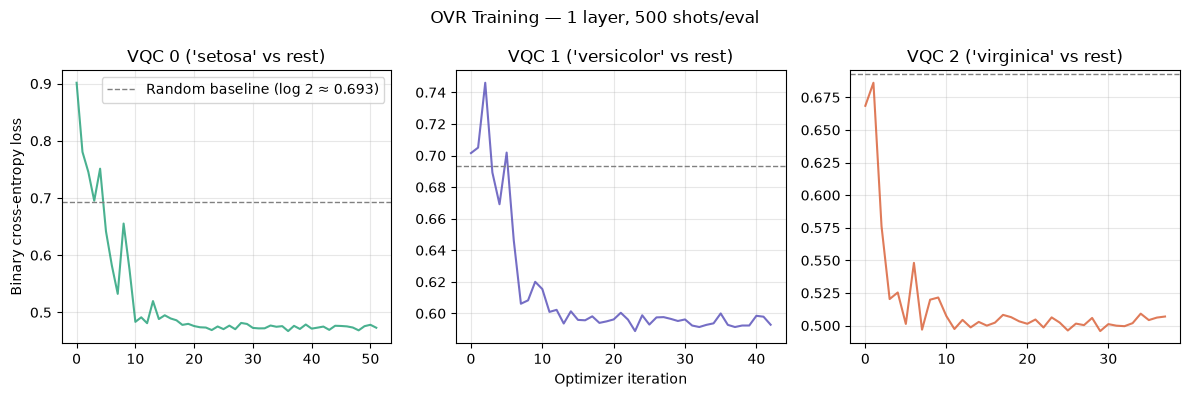

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ['#1D9E75', '#534AB7', '#D85A30']

for c in range(3):
    axes[c].plot(ovr_loss_history[c], color=colors[c], linewidth=1.5, alpha=0.8)
    if c == 0:
        axes[c].axhline(y=np.log(2), color='gray', linestyle='--',
                    linewidth=1, label='Random baseline (log 2 ≈ 0.693)')
        axes[c].set_ylabel("Binary cross-entropy loss")
        axes[c].legend()
    else:
        axes[c].axhline(y=np.log(2), color='gray', linestyle='--', linewidth=1)
    if c == 1:
        axes[c].set_xlabel("Optimizer iteration")
    axes[c].set_title(f"VQC {c} ('{iris.target_names[c]}' vs rest)")
    axes[c].grid(alpha=0.3)

plt.suptitle(f"OVR Training — {N_LAYERS} layer, {SHOTS} shots/eval", fontsize=12)
plt.tight_layout()
plt.savefig("../results/ovr_loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Notes
Setosa has the steepest change (0.9 -> ~0.48) which follows logically from it being linearly separable from the other two.

## Evaluation on Full Test Set
run all 3 OVR classifiers and take argmax for prediction

In [7]:
def ovr_predict(x, ovr_thetas, n_layers=1, shots=1000):
    '''
    Effect:
        predicts the class of x using one-vs-rest VQCs
        runs all 3 classifiers and returns the class with highest P(|1>)

    Requires:
        x: array-like, shape (4,)
            normalized feature vector
        ovr_thetas: dict {class_label: theta_vals}
            optimized parameters for each binary VQC
        n_layers: int
        shots: int

    Returns:
        predicted: int (0, 1, or 2)
        probs: dict {class_label: P(|1>)}
    '''
    probs = {}
    for c, theta_vals in ovr_thetas.items():
        qc, theta = build_vqc(x, n_layers=n_layers)
        probs[c] = get_prob(qc, theta, theta_vals, shots)
    predicted = max(probs, key=probs.get)

    return predicted, probs

In [8]:
# test trained 3-class VQC on the full Iris testing dataset
print(f"{'Sample':>6} | {'True':>4} | {'P0 (setosa)':>8} | {'P1 (versicolor)':>8} | {'P0 (virginica)':>8} | "
      f"{'Predicted':>9} | {'Correct':>5}")
print("-" * 83)

y_preds_ovr = []
y_probs_ovr = []
correct = 0

for i in range(len(X_test)):
    y_pred_ovr, y_prob_ovr = ovr_predict(X_test[i], ovr_thetas, n_layers=N_LAYERS)
    y_preds_ovr.append(y_pred_ovr)
    y_probs_ovr.append(y_prob_ovr)
    is_correct = y_pred_ovr == y_test[i]
    correct += is_correct
    print(f"{i:>6} | {y_test[i]:>4} | {y_prob_ovr[0]:>11.3f} | {y_prob_ovr[1]:>15.3f} | {y_prob_ovr[2]:>14.3f} | "
          f"{y_pred_ovr:>9} | {'✓' if is_correct else '✗':>5}")

print(f"accuracy with optimized parameters: {correct}/{len(X_test)}")

Sample | True | P0 (setosa) | P1 (versicolor) | P0 (virginica) | Predicted | Correct
-----------------------------------------------------------------------------------
     0 |    1 |       0.495 |           0.739 |          0.479 |         1 |     ✓
     1 |    0 |       0.604 |           0.561 |          0.265 |         0 |     ✓
     2 |    2 |       0.211 |           0.518 |          0.565 |         2 |     ✓
     3 |    1 |       0.516 |           0.653 |          0.465 |         1 |     ✓
     4 |    1 |       0.489 |           0.740 |          0.513 |         1 |     ✓
     5 |    0 |       0.730 |           0.518 |          0.113 |         0 |     ✓
     6 |    1 |       0.520 |           0.614 |          0.286 |         1 |     ✓
     7 |    2 |       0.301 |           0.301 |          0.511 |         2 |     ✓
     8 |    1 |       0.525 |           0.538 |          0.482 |         1 |     ✓
     9 |    1 |       0.483 |           0.662 |          0.365 |         1 |     ✓
 

## Confusion Matrix

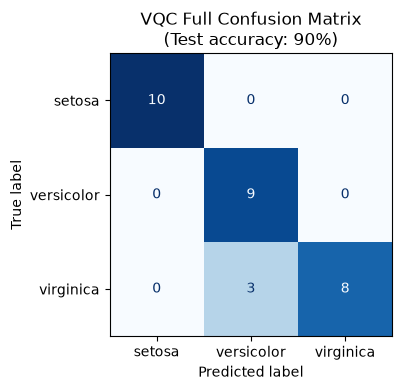

In [9]:
cm = confusion_matrix(y_test, y_preds_ovr)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=iris.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

accuracy = accuracy_score(y_test, y_preds_ovr)
ax.set_title(f"VQC Full Confusion Matrix\n(Test accuracy: {accuracy:.0%})")
plt.tight_layout()
plt.savefig("../results/vqc_full_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### Notes
True label setosa is always classified correctly. Model has trouble correctly classifying virginica samples but does pretty well with versicolor. Slight decrease from 100% accuracy in original 2-class model.

## Circuit Depth Ablation
test how accuracy changes with number of layers

In [11]:
ablation_results = {
    1: {
        'thetas': ovr_thetas,
        'accuracy': accuracy,
        'n_params': 4 * 1,
    }
}

In [12]:
for n in [2, 3]:
    print(f"Training OVR with {n} layers")
    thetas_n = {}
    
    for c in range(3):
        y_train_binary = make_binary_labels(y_train, c)
        theta_opt_n, _ = train(X_train, y_train_binary, n_layers=n, shots=SHOTS, maxiter=MAXITER, seed=42+c, verbose=True) # use a diff seed for each VQC

        thetas_n[c] = theta_opt_n
        print(f"Trained VQC {c}")
        print()

    # evaluate accuracy
    y_pred_n = []
    for x in X_test:
        pred, _ = ovr_predict(x, thetas_n, n, shots=SHOTS)
        y_pred_n.append(pred)
    
    accuracy_n = accuracy_score(y_test, y_pred_n)
    print(f"Depth {n}: {accuracy_n:.2} accuracy")
    print("-" * 20)
    ablation_results[n] = {
        'thetas': thetas_n,
        'accuracy': accuracy_n,
        'n_params': 4 * n
    }

Training OVR with 2 layers
Iter 25: loss = 0.1517
Iter 50: loss = 0.1499
Iter 75: loss = 0.1467
Trained VQC 0

Iter 25: loss = 0.5552
Iter 50: loss = 0.5598
Trained VQC 1

Iter 25: loss = 0.3893
Iter 50: loss = 0.3817
Iter 75: loss = 0.3809
Trained VQC 2

Depth 2: 0.97 accuracy
--------------------
Training OVR with 3 layers
Iter 25: loss = 0.2472
Iter 50: loss = 0.1973
Iter 75: loss = 0.1978
Iter 100: loss = 0.1999
Trained VQC 0

Iter 25: loss = 0.5288
Iter 50: loss = 0.4958
Iter 75: loss = 0.4839
Iter 100: loss = 0.4882
Trained VQC 1

Iter 25: loss = 0.3781
Iter 50: loss = 0.3128
Iter 75: loss = 0.3096
Iter 100: loss = 0.3124
Trained VQC 2

Depth 3: 0.93 accuracy
--------------------


### Notes
Both 2 and 3 layers are improvements from the 90% accuracy of 1 layer. Seems that 2 layers is the optimum - depth 3 is slightly less accurate perhaps because of more noise from more gates.

### Plot Ablation Results

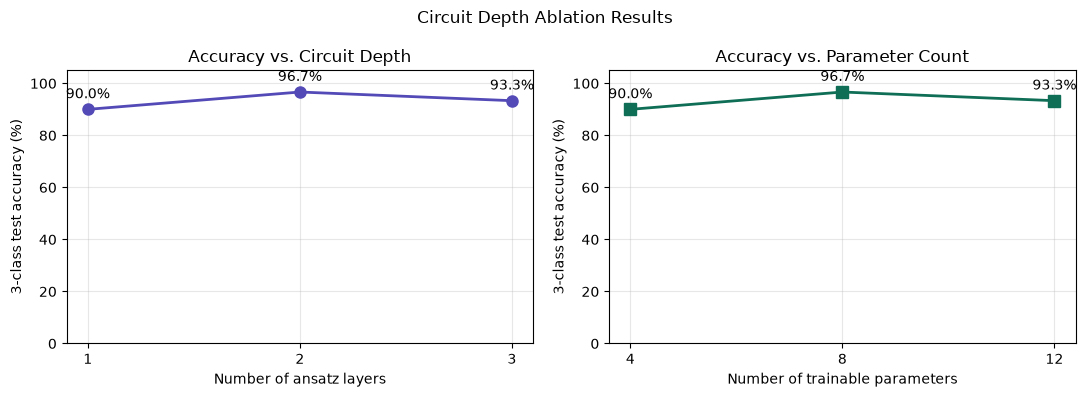

In [13]:
depths = sorted(ablation_results.keys())
accuracies = [ablation_results[d]['accuracy'] for d in depths]
n_params = [ablation_results[d]['n_params'] for d in depths]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# left: accuracy vs. depth
axes[0].plot(depths, [a * 100 for a in accuracies],
             'o-', color='#534AB7', linewidth=2, markersize=8)
axes[0].set_xlabel("Number of ansatz layers")
axes[0].set_ylabel("3-class test accuracy (%)")
axes[0].set_title("Accuracy vs. Circuit Depth")
axes[0].set_xticks(depths)
axes[0].set_ylim(0, 105)
axes[0].grid(alpha=0.3)
for d, a in zip(depths, accuracies):
    axes[0].annotate(f"{a:.1%}", (d, a*100),
                     textcoords="offset points", xytext=(0, 8),
                     ha='center', fontsize=10)

# right: accuracy vs number of parameters
axes[1].plot(n_params, [a * 100 for a in accuracies],
             's-', color='#0F6E56', linewidth=2, markersize=8)
axes[1].set_xlabel("Number of trainable parameters")
axes[1].set_ylabel("3-class test accuracy (%)")
axes[1].set_title("Accuracy vs. Parameter Count")
axes[1].set_xticks(n_params)
axes[1].set_ylim(0, 105)
axes[1].grid(alpha=0.3)
for n, a in zip(n_params, accuracies):
    axes[1].annotate(f"{a:.1%}", (n, a*100),
                     textcoords="offset points", xytext=(0, 8),
                     ha='center', fontsize=10)

plt.suptitle("Circuit Depth Ablation Results", fontsize=12)
plt.tight_layout()
plt.savefig("../results/depth_ablation.png", dpi=150, bbox_inches='tight')
plt.show()